In [4]:
import re
import numpy as np
from pathlib import Path
from scipy.io import wavfile

# -----------------------
# Justér her hvis nødvendigt
# -----------------------
IN_DIR = Path("keywords")             # hvor dine 30s keyword-filer ligger
OUT_DIR = IN_DIR / "spliced"              # outputmappe
WINDOW_S = 1.00                           # længde pr slice
PRE_S = 0.20                              # hvor meget før event-start vi tager med
MIN_GAP_S = 0.45                          # min afstand mellem to slices (undgå 2 ord i samme)
FRAME_MS = 20                             # energi frame
HOP_MS = 10                               # energi hop
THRESH_MULT = 6.0                         # threshold = median_energy * THRESH_MULT
MAX_SLICES_PER_FILE = 10                  # I forventer ~10; sæt 12 for lidt slack

# matcher fx "hest_A_0.75m_stille.001.wav"
FNAME_RE = re.compile(
    r"^(?P<label>[^_]+)_(?P<speaker>[A-Za-z])_(?P<dist>[0-9.]+m)_(?P<env>[^.]+)\.(?P<take>\d+)\.wav$",
    re.IGNORECASE
)

def to_mono(x: np.ndarray) -> np.ndarray:
    if x.ndim == 1:
        return x
    return x.mean(axis=1)

def moving_rms(x: np.ndarray, frame: int, hop: int) -> np.ndarray:
    if len(x) < frame:
        return np.array([], dtype=np.float32)
    n = 1 + (len(x) - frame) // hop
    rms = np.empty(n, dtype=np.float32)
    for i in range(n):
        seg = x[i * hop : i * hop + frame]
        rms[i] = np.sqrt(np.mean(seg * seg) + 1e-12)
    return rms

def detect_event_starts(rms: np.ndarray, thr: float, hop: int) -> np.ndarray:
    """Returnér sample-indeks for rising edges hvor rms krydser threshold."""
    if rms.size == 0:
        return np.array([], dtype=np.int64)
    above = rms > thr
    starts = np.where(np.logical_and(above, np.concatenate([[False], ~above[:-1]])))[0]
    return (starts * hop).astype(np.int64)

def sanitize(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-\.]+", "_", s)

def slice_one_file(wav_path: Path) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.float32)

    frame = int(fs * (FRAME_MS / 1000.0))
    hop = int(fs * (HOP_MS / 1000.0))

    rms = moving_rms(x, frame, hop)
    if rms.size == 0:
        return 0

    med = float(np.median(rms))
    thr = max(med * THRESH_MULT, 1e-6)

    starts = detect_event_starts(rms, thr, hop)

    # filtrér events for tæt på hinanden
    min_gap = int(fs * MIN_GAP_S)
    filtered = []
    last = -10**18
    for s in starts:
        if s - last >= min_gap:
            filtered.append(s)
            last = s
        if len(filtered) >= MAX_SLICES_PER_FILE:
            break

    if not filtered:
        return 0

    # parse filnavn for pæne slice-navne
    m = FNAME_RE.match(wav_path.name)
    if m:
        label = sanitize(m.group("label"))
        speaker = sanitize(m.group("speaker"))
        dist = sanitize(m.group("dist"))
        env = sanitize(m.group("env"))
        take = int(m.group("take"))
        base = f"{label}_{speaker}_{dist}_{env}_{take:03d}"
    else:
        base = sanitize(wav_path.stem)

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    win = int(fs * WINDOW_S)
    pre = int(fs * PRE_S)

    written = 0
    for i, s in enumerate(filtered, start=1):
        start = max(int(s - pre), 0)
        end = start + win
        if end > len(x):
            continue

        clip = x[start:end]
        clip = np.clip(clip, -32768, 32767).astype(np.int16)

        out_path = OUT_DIR / f"{base}_s{i:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def main():
    if not IN_DIR.exists():
        raise SystemExit(f"IN_DIR findes ikke: {IN_DIR.resolve()}")

    wavs = sorted([p for p in IN_DIR.glob("*.wav") if p.is_file()])
    print(f"Fandt {len(wavs)} keyword-filer i {IN_DIR}")

    total = 0
    for w in wavs:
        n = slice_one_file(w)
        print(f"{w.name}: {n} slices")
        total += n

    print("Total slices:", total)
    print("Output:", OUT_DIR.resolve())

if __name__ == "__main__":
    main()

Fandt 32 keyword-filer i keywords
får_A_0.75m_stille.001.wav: 10 slices
får_A_1.5m_stille.001.wav: 10 slices
får_C_0.75m_stille.001.wav: 10 slices
får_C_1.5m_stille.001.wav: 10 slices
får_J_0.75m_edison.001.wav: 10 slices
får_J_0.75m_stille.001.wav: 10 slices
får_J_1.5m_stille.001.wav: 10 slices
ged_A_0.75m_stille.001.wav: 10 slices
ged_A_1.5m_stille.001.wav: 10 slices
ged_C_0.75m_stille.001.wav: 10 slices
ged_C_1.5m_stille.001.wav: 10 slices
ged_J_0.75m_stille.001.wav: 10 slices
ged_J_1.5m_stille.001.wav: 10 slices
hest_A_0.75m_stille.001.wav: 10 slices
hest_A_1.5m_stille.001.wav: 10 slices
hest_C_0.75m_stille.001.wav: 10 slices
hest_C_1.5m_stille.001.wav: 10 slices
hest_J_0.75m_edison.001.wav: 10 slices
hest_J_0.75m_stille.001.wav: 10 slices
hest_J_1.5m_stille.001.wav: 10 slices
laks_A_0.75m_stille.001.wav: 10 slices
laks_A_1.5m_stille.001.wav: 10 slices
laks_C_0.75m_stille.001.wav: 10 slices
laks_C_1.5m_stille.001.wav: 10 slices
laks_J_0.75m_stille.001.wav: 10 slices
laks_J_1.5m_sti

Valgte filer:
 - ged_A_0.75m_stille_001_s01.wav
 - ged_A_0.75m_stille_001_s02.wav
 - ged_A_0.75m_stille_001_s03.wav
 - ged_A_0.75m_stille_001_s04.wav
 - ged_A_0.75m_stille_001_s05.wav
 - ged_A_0.75m_stille_001_s06.wav
 - ged_A_0.75m_stille_001_s07.wav
 - ged_A_0.75m_stille_001_s08.wav


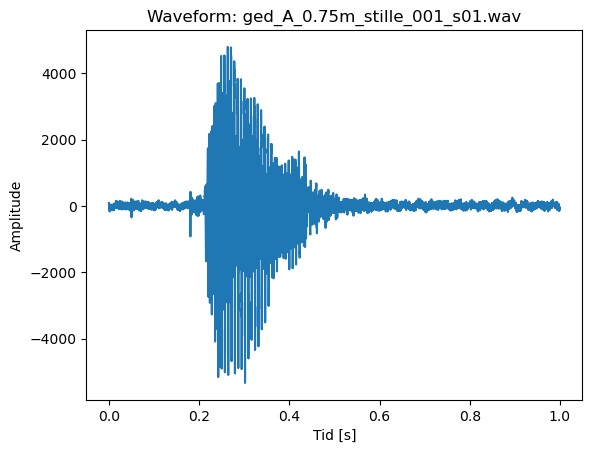

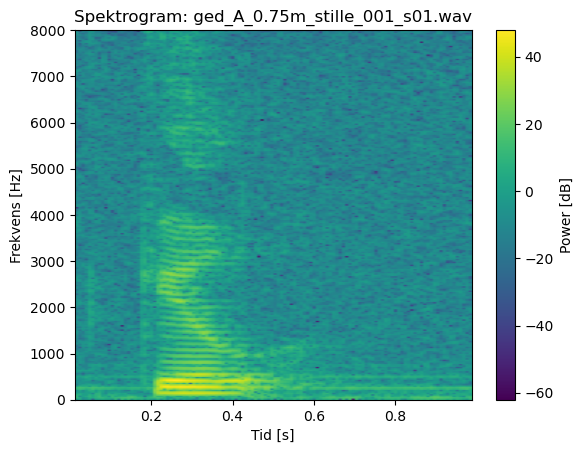

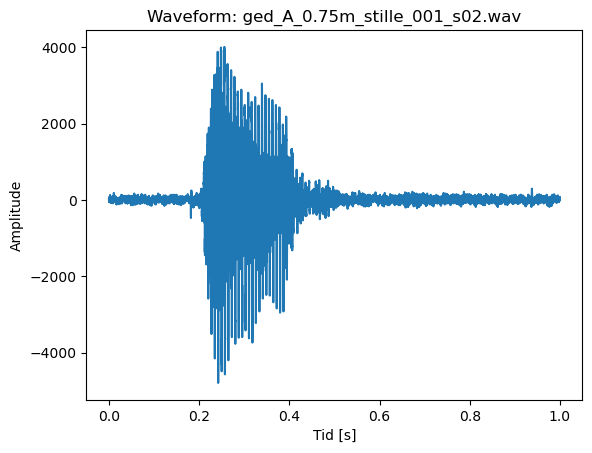

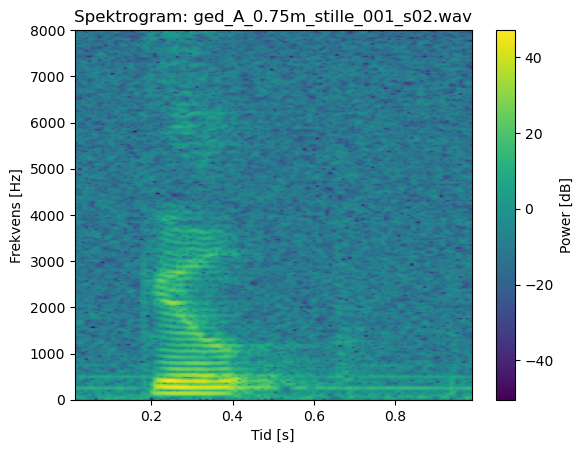

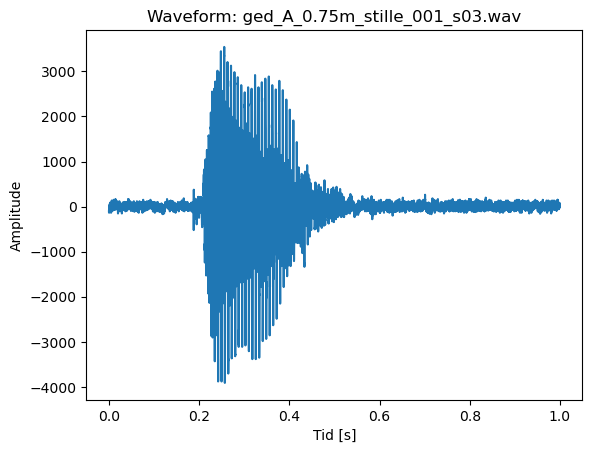

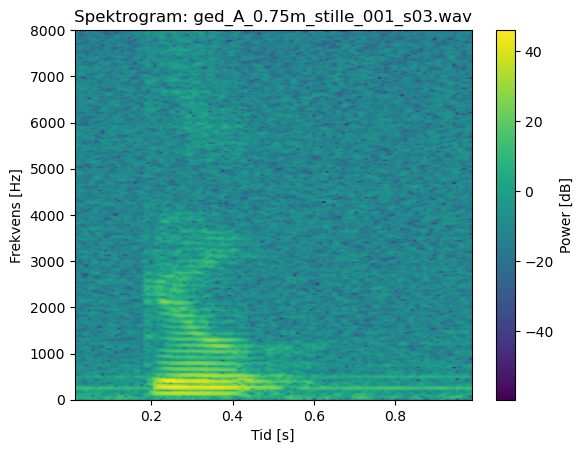

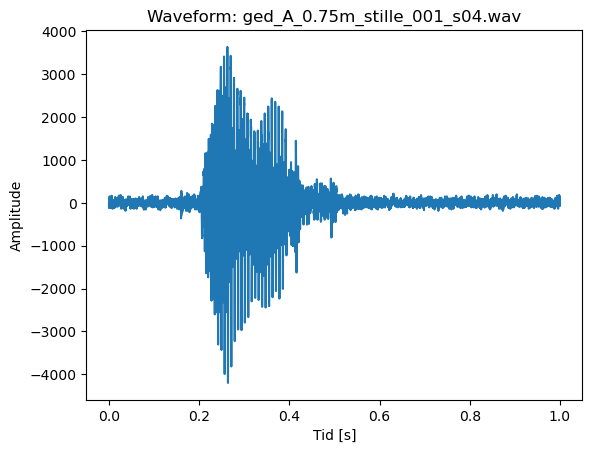

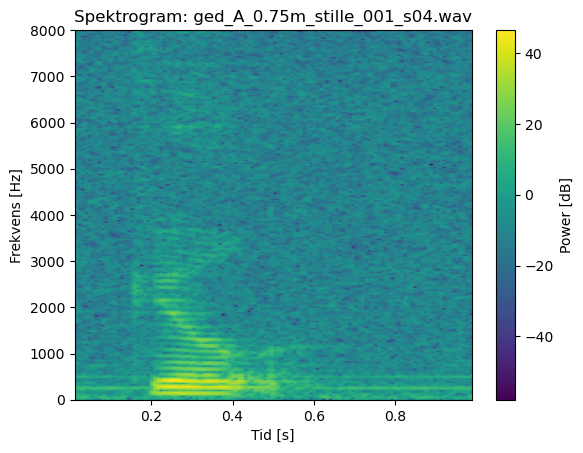

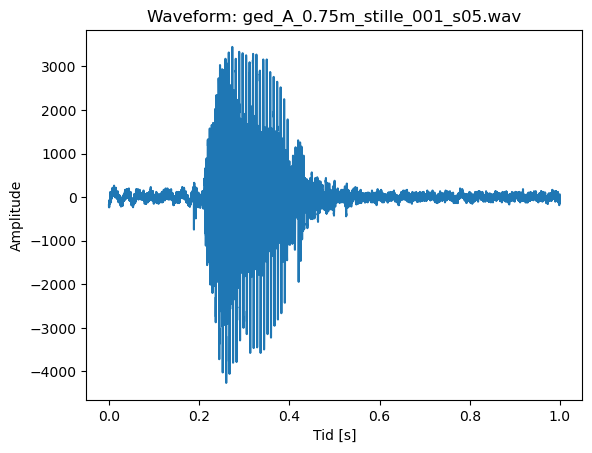

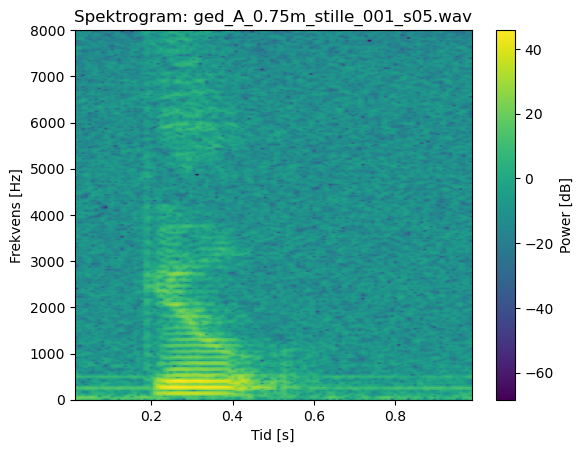

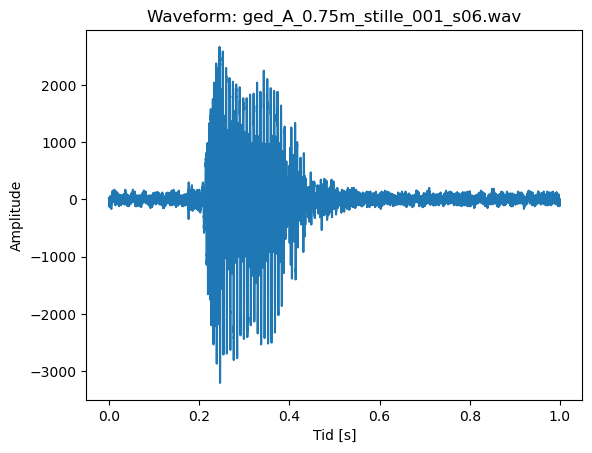

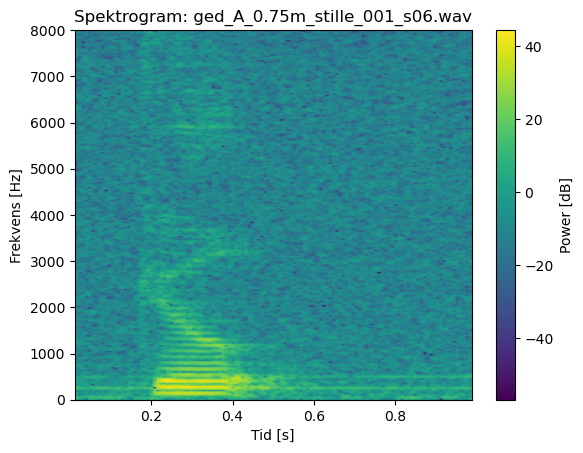

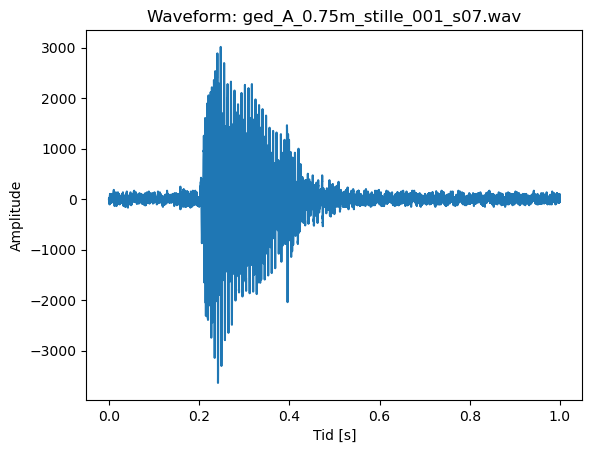

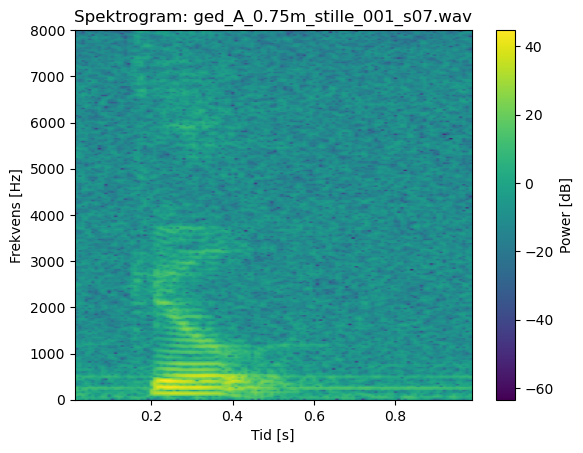

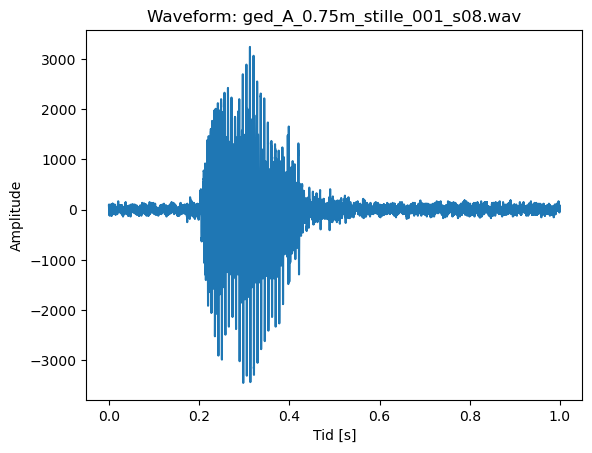

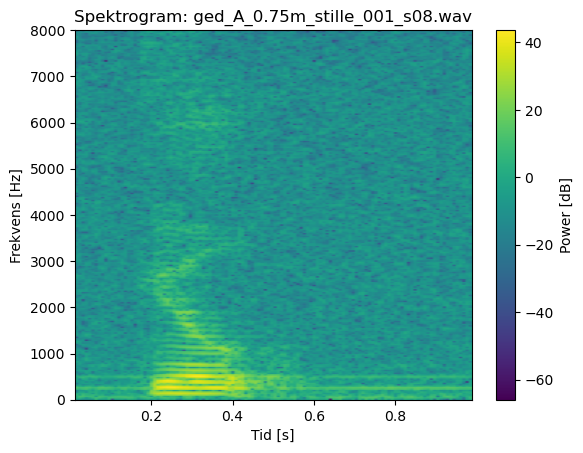

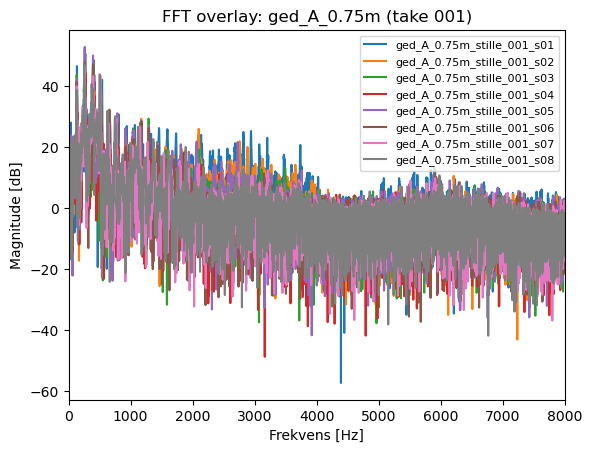

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile

# -----------------------------
# 1) RET DISSE TO
# -----------------------------
SPLICED_DIR = Path(r"keywords\spliced")   # <-- ret til din spliced-mappe
BASE_PREFIX = "ged_A_0.75m"                       # <-- start med denne (kan udvides)
TAKE_ID = "001"                                  # <-- din take (001)
MAX_FILES = 10                                    # <-- hvor mange slices du vil plotte ad gangen
# -----------------------------

def read_wav_mono(path: Path):
    fs, x = wavfile.read(path)
    if x.ndim == 2:
        x = x.mean(axis=1)
    # til float for beregninger
    x = x.astype(np.float32)
    # fjern DC
    x = x - np.mean(x)
    return fs, x

def compute_fft(fs: int, x: np.ndarray):
    # Vindue for pænere spektrum
    w = np.hanning(len(x)).astype(np.float32)
    xw = x * w
    X = np.fft.rfft(xw)
    f = np.fft.rfftfreq(len(xw), 1.0/fs)
    mag = np.abs(X) / (np.sum(w) / 2.0)  # grov amplitude-normalisering
    mag_db = 20*np.log10(mag + 1e-12)
    return f, mag_db

def plot_waveform(fs, x, title):
    t = np.arange(len(x)) / fs
    plt.figure()
    plt.plot(t, x)
    plt.xlabel("Tid [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.show()

def plot_fft_overlay(results, title, fmax=None):
    plt.figure()
    for (name, f, mag_db) in results:
        plt.plot(f, mag_db, label=name)
    plt.xlabel("Frekvens [Hz]")
    plt.ylabel("Magnitude [dB]")
    plt.title(title)
    if fmax is not None:
        plt.xlim(0, fmax)
    plt.legend(fontsize=8)
    plt.show()

def plot_spectrogram(fs, x, title, fmax=None):
    # NFFT/overlap typisk for tale
    NFFT = int(0.032 * fs)   # 32 ms
    NFFT = max(NFFT, 256)
    noverlap = int(0.75 * NFFT)

    plt.figure()
    Pxx, freqs, bins, im = plt.specgram(
        x,
        NFFT=NFFT,
        Fs=fs,
        noverlap=noverlap,
        scale="dB",
        mode="psd"
    )
    plt.xlabel("Tid [s]")
    plt.ylabel("Frekvens [Hz]")
    plt.title(title)
    if fmax is not None:
        plt.ylim(0, fmax)
    plt.colorbar(label="Power [dB]")
    plt.show()

def find_files():
    if not SPLICED_DIR.exists():
        raise SystemExit(f"Folder findes ikke: {SPLICED_DIR.resolve()}")

    # Matcher fx:
    # ged_A_0.75m_stille_001_s03.wav
    # ged_A_0.75m_stille_001_s10.wav
    # Hvis dine navne er lidt anderledes, så justér filteret her.
    files = sorted([p for p in SPLICED_DIR.glob("*.wav") if p.is_file()])

    chosen = []
    for p in files:
        name = p.stem  # uden .wav
        # Krav:
        # - starter med "ged_A_0.75m"
        # - indeholder "_001_" et sted (take)
        # - indeholder "_sXX" til sidst
        if name.startswith(BASE_PREFIX) and f"_{TAKE_ID}_" in name and "_s" in name:
            chosen.append(p)

    return chosen[:MAX_FILES]

def main():
    files = find_files()
    print("Valgte filer:")
    for p in files:
        print(" -", p.name)

    fft_results = []

    for p in files:
        fs, x = read_wav_mono(p)

        # 1) Waveform (vis én ad gangen)
        plot_waveform(fs, x, f"Waveform: {p.name}")

        # 2) FFT (gem til overlay)
        f, mag_db = compute_fft(fs, x)
        fft_results.append((p.stem, f, mag_db))

        # 3) Spektrogram (vis én ad gangen)
        plot_spectrogram(fs, x, f"Spektrogram: {p.name}", fmax=8000)

    # FFT overlay til sidst (så du kan sammenligne slices direkte)
    if fft_results:
        plot_fft_overlay(fft_results, f"FFT overlay: {BASE_PREFIX} (take {TAKE_ID})", fmax=8000)

if __name__ == "__main__":
    main()